## Introduction
Air travel is one of those experiences where a minor inconvenience can quickly become a public complaint. A delayed flight, a missing bag, or a long hold time can turn into a frustrated tweet within seconds. For airlines, these tweets matter because they are both customer service requests and public-facing reputation risks.

This project develops a multiclass sentiment classifier for airline-related tweets. The model predicts whether a tweet is negative, neutral, or positive. In the project scenario, the model would support the social media team of a major U.S. airline in 2015 by helping customer service representatives identify negative tweets that may require a human response, while allowing positive tweets to be acknowledged more efficiently.

In this setting, different classification errors carry different consequences. Missing a negative tweet could mean ignoring a dissatisfied customer, while incorrectly labeling a neutral tweet as negative mainly creates extra work for the social media team. Because of that, this report evaluates the model not only by overall accuracy, but also by class-specific precision, recall, and F1-score, with special attention to how well the model identifies negative tweets.

## Methods

In [2]:
# Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

# Load Data
tweets = pd.read_parquet(
    "https://lab.cs307.org/tweets/data/tweets.parquet",
)

# Data Splitting
X = tweets["text"]
y = tweets["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=.2,
    random_state=307, 
    stratify=y
)

### Data
The dataset contains tweets directed at major U.S. airlines in 2015. Each row represents one tweet and includes the airline mentioned, the full tweet text, and a sentiment label. The response variable is `sentiment`, which classifies each tweet as negative, neutral, or positive. The main feature used for modeling is `text`, which contains the raw tweet content.

The `airline` variable was included in the dataset but was not used in the final model. This modeling approach focuses on whether the language of the tweet alone can support sentiment classification. This makes the model more general, since it learns patterns in customer language rather than relying on airline-specific complaint patterns.

The data were split into training and test sets using an 80/20 split. Because the sentiment classes are imbalanced, a stratified split was used so that the training and test sets preserved similar class proportions. The training data were used for model development and cross-validation, while the test data were held out until final evaluation. This gives a more honest estimate of how the model would perform on new tweets.

#### Data Dictionary 
| Variable | Role | Description |
|---|---|---|
| `sentiment` | Response | Human-labeled sentiment of the tweet: negative, neutral, or positive. |
| `text` | Feature | Full text content of the tweet. |
| `airline` | Feature | Airline referenced by the tweet. This variable was available but not used in the final model. |

### Exploratory Analysis
The sentiment distribution shows that negative tweets are the most common class. This is not surprising given the context: people are more likely to tweet at an airline when something has gone wrong than when everything goes smoothly. However, this imbalance matters for modeling. A classifier that simply predicts every tweet as negative can achieve a decent-looking accuracy score without actually understanding sentiment.

For that reason, accuracy alone is not enough to evaluate this model. A useful airline support model needs to do more than identify the majority class. It needs to separate genuinely negative tweets from neutral questions and positive comments so that the social media team can respond appropriately.

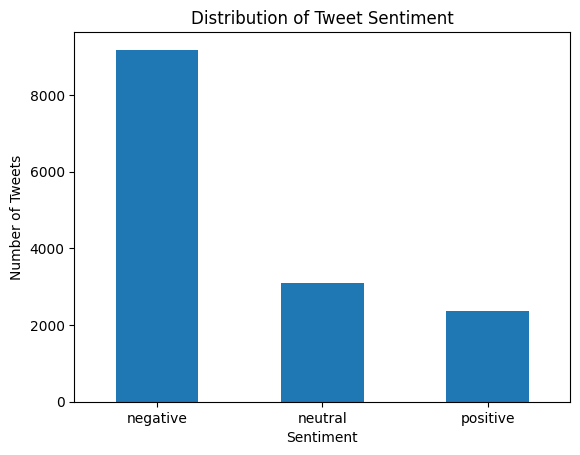

In [3]:
#| label: fig-sentiment-distribution
#| fig-cap: "Distribution of sentiment labels in the airline tweet dataset. Negative tweets are the most common class, which makes accuracy alone a potentially misleading measure of model performance."
#| echo: false

sentiment_counts = tweets["sentiment"].value_counts().loc[
    ["negative", "neutral", "positive"]
]

ax = sentiment_counts.plot(kind="bar")

ax.set_title("Distribution of Tweet Sentiment")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Number of Tweets")

plt.xticks(rotation=0)
plt.show()

The sentiment distribution shows that negative tweets are the most common class. his is not surprising given the context: people are more likely to tweet at an airline when something has gone wrong than when everything goes smoothly. This matters because a model can achieve a decent-looking accuracy score simply by predicting the majority class. Since the goal is to support customer service triage, the model must be evaluated using class-specific metrics such as recall and F1-score, not accuracy alone.

A useful airline support model needs to do more than identify the majority class. It needs to separate genuinely negative tweets from neutral questions and positive comments so that the social media team can respond appropriately. 

In [4]:
# Pipeline
pipeline = Pipeline([
    (
        "vectorizer",
        TfidfVectorizer()
    ),
    (
        "classifier",
        LogisticRegression(max_iter=2000)
    )
])

# Define Parameter Grid for the Vectorizer
param_grid = {
    "vectorizer__max_features": [3000, 5000, 10000],
    "vectorizer__ngram_range": [(1,1), (1,2)],
    "vectorizer__stop_words": [None, "english"],
    "classifier__C": [0.1, 1, 10],
    "vectorizer__min_df": [1, 2, 5],
    "vectorizer__max_df": [.9, .95, 1.0]
}

# Running Grid Search
grid_search = GridSearchCV(
    pipeline,
    param_grid, 
    cv=5, 
    scoring="f1_weighted", 
    n_jobs=-1 
)

# Model Fitting
_ = grid_search.fit(X_train, y_train)

/home/avahfk2/cs307/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


### Modeling
Since the main input is raw tweet text, the text first had to be converted into numeric features. TF-IDF vectorization was used to represent each tweet based on the importance of its words or phrases relative to the full training corpus. This is useful for sentiment analysis because common words are downweighted, while more informative terms such as “delayed,” “cancelled,” or “thanks” can carry more influence.

The classifier used was multinomial logistic regression. Logistic regression is a strong choice for this task because it works well with sparse, high-dimensional text data and remains interpretable. That interpretability matters in this setting: if the model is going to support customer service decisions, it is useful to understand which words are pushing predictions toward negative, neutral, or positive sentiment.

Model development was handled with a pipeline containing the TF-IDF vectorizer and logistic regression classifier. This pipeline structure is important because it prevents data leakage. During cross-validation, the vectorizer is fit only on the training fold, not on the validation fold, which better simulates how the model would behave on unseen tweets.

GridSearchCV with 5-fold cross-validation was used to tune both the text representation and the classifier. The grid included vocabulary size, unigram versus bigram features, stop word removal, minimum and maximum document frequency thresholds, and the logistic regression regularization parameter C. The final model was selected using weighted F1-score because the task has multiple classes and an imbalanced label distribution. After selection, the final model was evaluated on the held-out test set.

In [5]:
# Final Test Evaluation
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)

## Results
The selected TF-IDF logistic regression model achieved a test accuracy of approximately 0.80. This improves substantially over the majority-class baseline, which achieved an accuracy of approximately 0.63 by predicting every tweet as negative. That baseline is useful because it shows why accuracy can be misleading in this project. The baseline looks somewhat respectable on accuracy, but it completely fails to identify neutral and positive tweets.

The selected model performed especially well on negative tweets, with precision of 0.84, recall of 0.91, and an F1-score of 0.87. This is the most important class for the project scenario because negative tweets are the ones most likely to require a timely customer service response. The model correctly identifies most tweets labeled as negative, which makes it useful as a first-pass triage tool.

Performance was weaker on neutral tweets, with recall of 0.57 and an F1-score of 0.60. This makes sense in context because neutral tweets often resemble both complaints and routine customer service questions. For example, a customer asking about a flight change may sound similar to a frustrated customer complaining about a delay. Positive tweets were classified more successfully than neutral tweets, with recall of 0.66 and an F1-score of 0.73.

Overall, the model is doing much more than simply repeating the majority class. The baseline weighted F1-score was approximately 0.48, while the selected model achieved a weighted F1-score of approximately 0.79. The improvement in macro F1-score is also important because it shows that the model learned to classify minority classes instead of only performing well on negative tweets.

In [6]:
# Baseline Model Comparison
majority_class = y_train.value_counts().idxmax()

baseline_pred = np.repeat(majority_class, len(y_test))

baseline_accuracy = accuracy_score(y_test, baseline_pred)

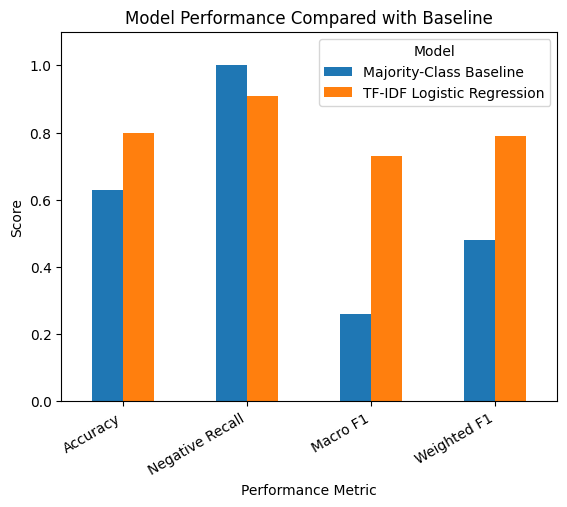

In [7]:
#| label: fig-model-comparison
#| fig-cap: "Comparison of the majority-class baseline and selected TF-IDF logistic regression model across multiple performance metrics. The selected model improves substantially in macro F1 and weighted F1, showing stronger classification across all sentiment classes."
#| echo: false

model_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Negative Recall",
        "Macro F1",
        "Weighted F1",
    ],
    "Majority-Class Baseline": [
        0.63,
        1.00,
        0.26,
        0.48,
    ],
    "TF-IDF Logistic Regression": [
        0.80,
        0.91,
        0.73,
        0.79,
    ],
})

ax = model_comparison.plot(
    x="Metric",
    y=["Majority-Class Baseline", "TF-IDF Logistic Regression"],
    kind="bar",
)

ax.set_title("Model Performance Compared with Baseline")
ax.set_xlabel("Performance Metric")
ax.set_ylabel("Score")
ax.legend(title="Model")

plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1.1)
plt.show()

The model comparison shows why the majority-class baseline is not actually useful despite its moderate accuracy. The baseline achieves perfect negative recall only because it predicts every tweet as negative, but it completely fails to identify neutral and positive tweets. The selected TF-IDF logistic regression model has slightly lower negative recall, but much stronger macro F1 and weighted F1, indicating more balanced performance across all sentiment classes. The selected model is more useful in practice because it still identifies most negative tweets while also recognizing neutral and positive messages. 

### Confusion Matrix

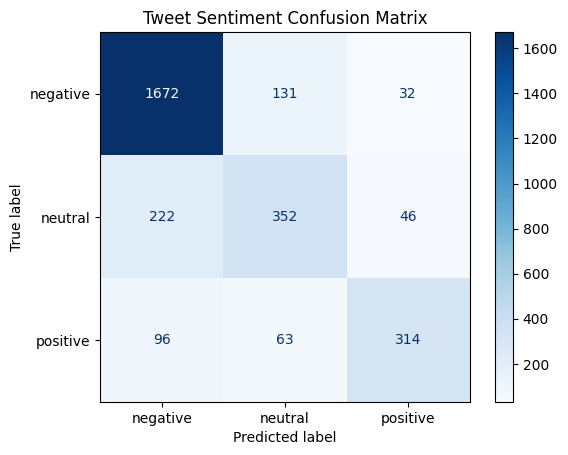

In [8]:
#| label: fig-confusion-matrix
#| fig-cap: "Confusion matrix for the selected TF-IDF logistic regression model on the held-out test set. The model correctly identifies most negative tweets, but neutral tweets are more frequently confused with negative or positive sentiment."
#| echo: false

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Tweet Sentiment Confusion Matrix")
plt.show()

The confusion matrix shows that the model correctly classified 1,672 of 1,835 negative tweets. The most common mistake for negative tweets was predicting them as neutral, while fewer negative tweets were predicted as positive. From a customer service perspective, this distinction matters. A negative tweet classified as neutral may still remain in a lower-priority review queue, but a negative tweet classified as positive could trigger an inappropriate automated response.

The model also incorrectly classifies some neutral and positive tweets as negative. This would create extra work for customer service representatives, but that error is less risky than ignoring a genuinely frustrated customer. In this use case, a false alarm is inconvenient; a missed complaint can become a public service failure.

### Error Analysis

In [9]:
misclassified = pd.DataFrame({
    "tweet": X_test,
    "actual": y_test,
    "predicted": y_pred
})

misclassified = misclassified[
    misclassified["actual"] != misclassified["predicted"]
]


negative_missed = misclassified[
    (misclassified["actual"] == "negative") &
    (misclassified["predicted"] != "negative")
]

#| echo: false

negative_missed[["tweet", "actual", "predicted"]].head(5)

,tweet,actual,predicted
13031,@AmericanAir will do on another airline that's...,negative,neutral
5675,@SouthwestAir can you answer the phone so I ca...,negative,neutral
469,@VirginAmerica Man of steel flies to more citi...,negative,positive
10950,@USAirways we got 1 drink then F/A sat in jump...,negative,positive
6495,@SouthwestAir Any plans to make the southwest ...,negative,neutral


A review of missed negative tweets suggests that some errors involve sarcasm, short ambiguous messages, or customer service questions that contain negative context without obvious complaint words. These examples support the decision to use the model for triage rather than full automation.

### Model Interpretability

In [10]:
vectorizer = best_model.named_steps["vectorizer"]
classifier = best_model.named_steps["classifier"]

feature_names = vectorizer.get_feature_names_out()
class_labels = classifier.classes_

feature_importance_rows = []

for class_index, class_label in enumerate(class_labels):
    coefficients = classifier.coef_[class_index]
    top_indices = np.argsort(coefficients)[-15:]
    
    for index in top_indices[::-1]:
        feature_importance_rows.append({
            "sentiment": class_label,
            "feature": feature_names[index],
            "coefficient": coefficients[index],
        })

feature_importance_df = pd.DataFrame(feature_importance_rows)

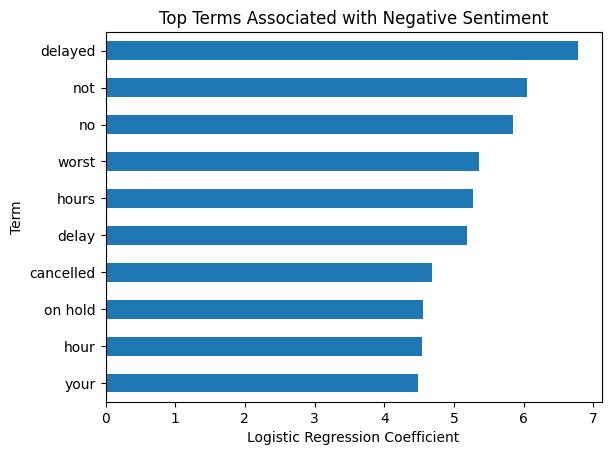

In [11]:
#| label: fig-negative-feature-importance
#| fig-cap: "Top terms most strongly associated with negative sentiment in the selected logistic regression model. The highest-weighted terms reflect common airline service problems such as delays, cancellations, waiting, and luggage issues."
#| echo: false

negative_features = feature_importance_df[
    feature_importance_df["sentiment"] == "negative"
].head(10)

ax = negative_features.sort_values("coefficient").plot(
    x="feature",
    y="coefficient",
    kind="barh",
    legend=False,
)

ax.set_title("Top Terms Associated with Negative Sentiment")
ax.set_xlabel("Logistic Regression Coefficient")
ax.set_ylabel("Term")

plt.show()

The model coefficients provide evidence that the classifier learned meaningful sentiment signals. Terms most strongly associated with negative sentiment included “worst,” “hours,” “delayed,” “hold,” “cancelled,” “stuck,” and “luggage.” These words reflect common airline pain points; customers complain when flights are delayed, bags are lost, or they are stuck waiting for help.

Neutral terms included words such as “hi,” “can,” and “possible,” which are consistent with informational requests rather than emotional reactions. This supports the idea that the model is identifying language patterns that are relevant to the customer service setting.

## Discussion 
This model should be used in practice, but only as a decision-support tool rather than a fully automated customer service system. The model is strong enough to help prioritize tweets because it identifies most negative tweets, with negative recall of 0.91 on the held-out test set. For a social media team, that could be valuable: representatives could focus first on tweets most likely to involve frustrated customers, delays, cancellations, or service problems.

The model also provides a clear improvement over the majority-class baseline. The baseline technically catches every negative tweet, but only because it treats every customer as angry. That is not a realistic workflow. It would overwhelm representatives and eliminate the benefit of separating complaints from routine questions or positive comments. The selected model offers a better balance by identifying most negative tweets while still recognizing neutral and positive messages.

That said, the model should not operate without human oversight. Some negative tweets are still missed, and those are the highest-risk errors in this scenario. A false negative could mean that an upset customer does not receive help. A negative tweet classified as positive is even worse, because the airline could send a cheerful automated acknowledgment to someone who is clearly frustrated. That kind of mistake would not just be inaccurate; it could make the company look careless.

The model also struggles with neutral tweets. This limitation is understandable because neutral airline tweets often contain customer service language that overlaps with both complaints and praise. A tweet asking about a flight change may look similar to a complaint about a delay, especially when the model only sees text and not the full customer context.

Because of these limitations, the model should be deployed as a triage system with guardrails. Tweets predicted as negative should be routed to customer service representatives first. Tweets predicted as neutral should remain available for review, but with lower urgency. Positive tweets could be automatically acknowledged only when the model is highly confident. This approach uses the model where it is most helpful while avoiding the risk of letting it make final customer service decisions on its own.

Future improvements should focus on reducing the most costly errors. One option would be to tune the model specifically for negative recall, even if that slightly reduces precision. Another would be to adjust prediction thresholds so the model is more cautious before labeling a tweet as positive. Including the `airline` feature may also improve performance, since different airlines may receive different types of complaints. Additional preprocessing for URLs, user mentions, sarcasm, and negation could also help the model better understand the informal style of tweets.

## Conclusion 
In conclusion, this model is recommended as a support tool for social media triage, not as a replacement for human judgment. Its high recall for negative tweets makes it useful for identifying customers who may need help, and its improvement over the baseline shows that it has learned meaningful language patterns. However, because some negative tweets are still missed and neutral tweets remain difficult to classify, the model should be deployed with human review and confidence-based safeguards. In an airline customer service setting, the model’s value is not that it can perfectly understand every tweet, but that it can help the team find the urgent ones faster.